In [1]:
%matplotlib widget

Per ogni sorgente modificare:
- z e controllare che lambda lines corrisponda
- sigma e seeing
- n_component
- regione estrazione cielo
- taglio immagine in y
- funzioni di plot e model_convolved
- bounds_HA (ampiezza dell'intervallo sulle x è +- la metà del seeing) e bounds
- salvataggio fit

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC4904/FORS2.2022-02-07T08_36_57.209/NGC-4904_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC4904/FORS2.2022-02-07T08_36_57.209/NGC-4904_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     367   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        66   (2094, 964)   float32   


In [4]:
image_cut = image[49:149, 0:1890]
image_error_cut = image_error[49:149, 0:1890]

Text(0.5, 0, 'wavelength')

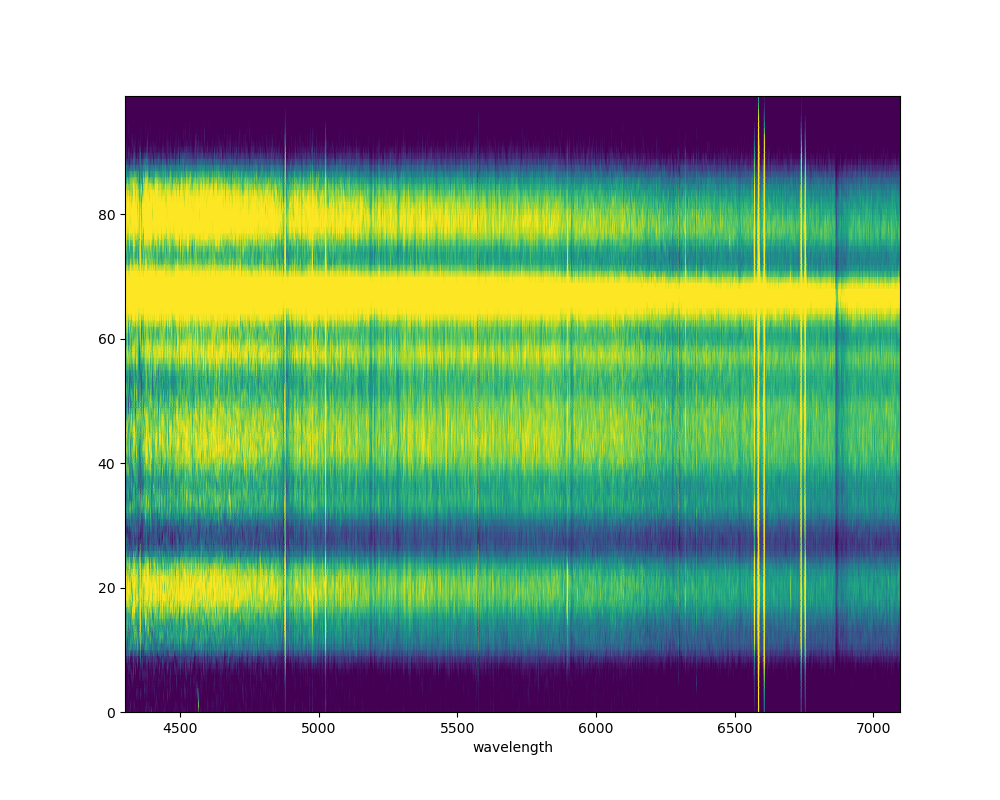

In [5]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10,8))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

## Redshift or the lines in air

In [6]:
z = 0.00394
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC4904/FORS2.2022-02-07T08_36_57.209/PSF/Real_seeing_NGC4904.txt")
sigmas = seeing / 2.35
n_component = 5
print(sigmas)

[1.51856596 1.65489801 1.51814012 1.51674365 1.63857526 1.51957447]


In [7]:
l_HA

6588.85822

## Sky lines

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC4904/FORS2.2022-02-07T08_36_57.209/NGC-4904_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     367   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        66   (2094, 964)   float32   


Text(0.5, 0, 'wavelength')

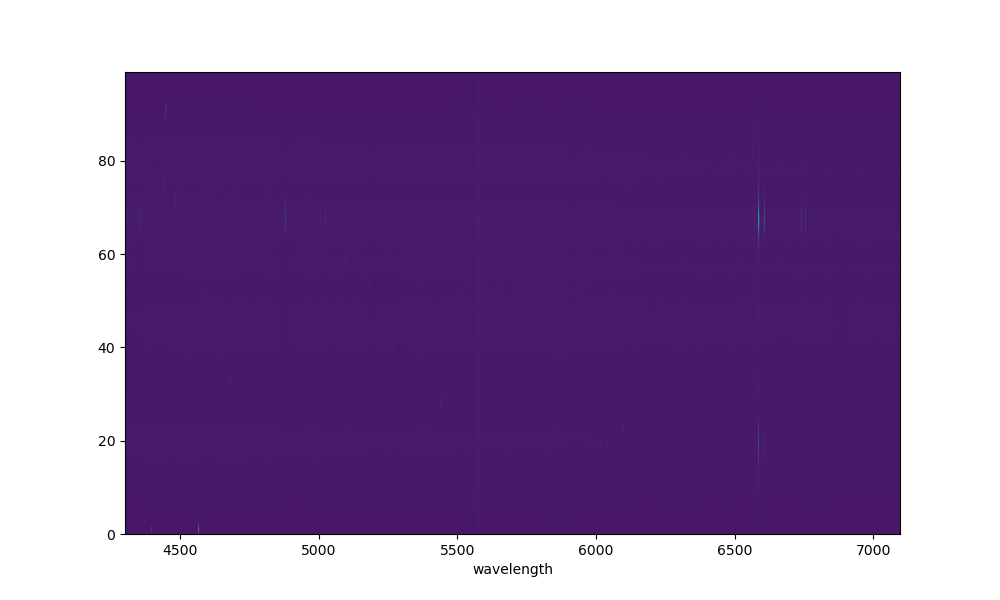

In [8]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC4904/FORS2.2022-02-07T08_36_57.209/NGC-4904_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[49:149, 0:1890]

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10, 6))
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

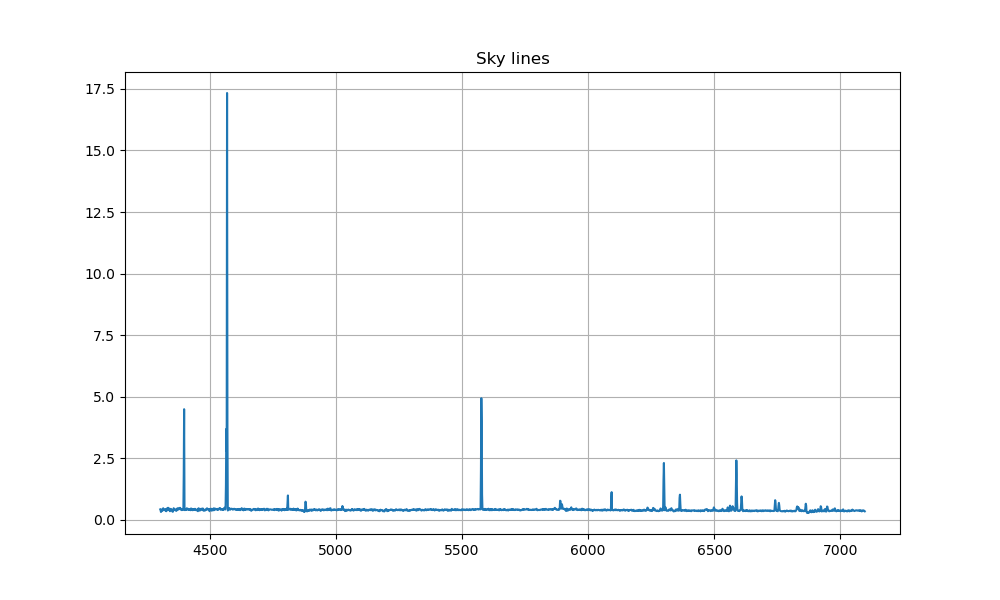

In [9]:
mask_sky = (y > 0)*(y < 8)
mask_wv = wv > 4303
image_sky = image_cut2[np.ix_(mask_sky, mask_wv)]
radial_profile_sky = np.sum(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wv[mask_wv], radial_profile_sky)

plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

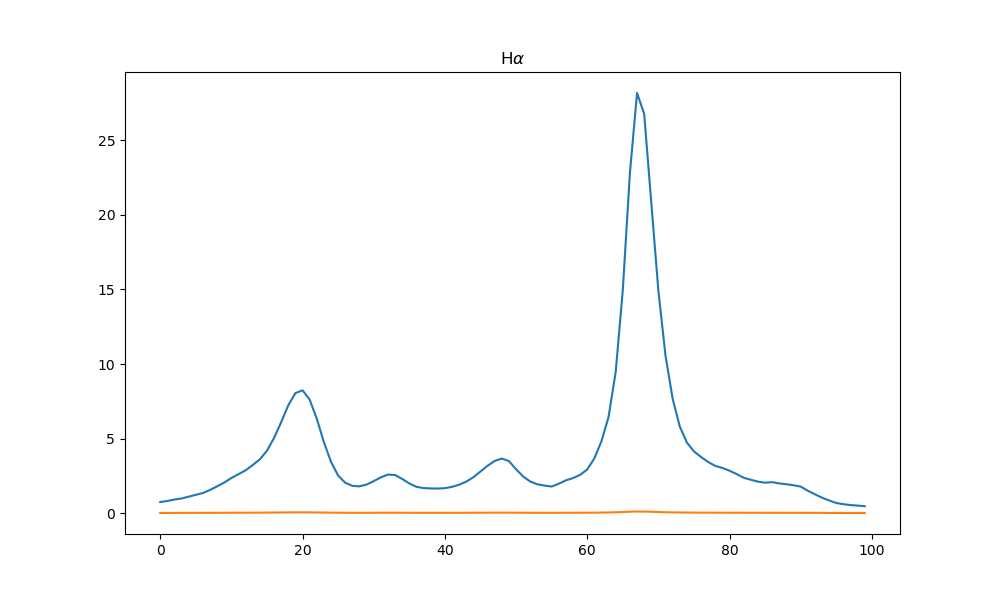

In [10]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

sky_err = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC4904/Propagazione_errori/Sky_errors.txt")
real_errors_HA = np.sqrt(radial_profile_error_HA**2+(sky_err[2])**2+(0.04*radial_profile_HA)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [11]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) #+
        #sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs, sigma):
    y_model = model_convolved(x, sigma, *params)
    return np.sum((y_obs - y_model)**2)

def sersic_1d_convolved(x, I_e, r_e, n, x_0, sigma):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 30)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 30)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

bounds_HA = [

    (0, 20),
    (0, 50),
    (0.1, 10),
    (19.5, 21),
    
    (0, 5),
    (0, 5),
    (0.1, 10),
    (31.8, 32.8),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (45, 55),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (60, 70),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (79, 82)
]

def save_params(params_curve, covariance, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, sigma, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, dof, chi2

def save_params_diff(params_curve, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    param_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    
    output_dir = "Diff_params"
    os.makedirs(output_dir, exist_ok=True)

    # Salva file CSV nella cartella Diff_params
    if line_name:
        param_filename = os.path.join(output_dir, f"{line_name}_{output_prefix}_diff.csv")
    
    df_params.to_csv(param_filename, float_format='%.4f')

In [12]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 95280.88244199453
differential_evolution step 2: f(x)= 38823.94008828731
differential_evolution step 3: f(x)= 19204.329995586908
differential_evolution step 4: f(x)= 19204.329995586908
differential_evolution step 5: f(x)= 8303.721161689075
differential_evolution step 6: f(x)= 8303.721161689075
differential_evolution step 7: f(x)= 4294.095239285199
differential_evolution step 8: f(x)= 1573.6464896866094
differential_evolution step 9: f(x)= 1573.6464896866094
differential_evolution step 10: f(x)= 1573.6464896866094
differential_evolution step 11: f(x)= 1573.6464896866094
differential_evolution step 12: f(x)= 1573.6464896866094
differential_evolution step 13: f(x)= 1573.6464896866094
differential_evolution step 14: f(x)= 1573.6464896866094
differential_evolution step 15: f(x)= 1573.6464896866094
differential_evolution step 16: f(x)= 1573.6464896866094
differential_evolution step 17: f(x)= 1454.0258871173494
differential_evolution step 18: f(x)= 1454.02

Sérsic 1: I_e=0.3232, r_e=34.9402, n=2.1525, x_0=19.5020
Sérsic 2: I_e=1.2305, r_e=1.0516, n=0.3866, x_0=32.7550
Sérsic 3: I_e=0.7529, r_e=7.1215, n=0.9349, x_0=47.6050
Sérsic 4: I_e=1.8992, r_e=7.6934, n=2.1857, x_0=67.3792
Sérsic 5: I_e=1.4042, r_e=10.4705, n=0.3079, x_0=79.6134


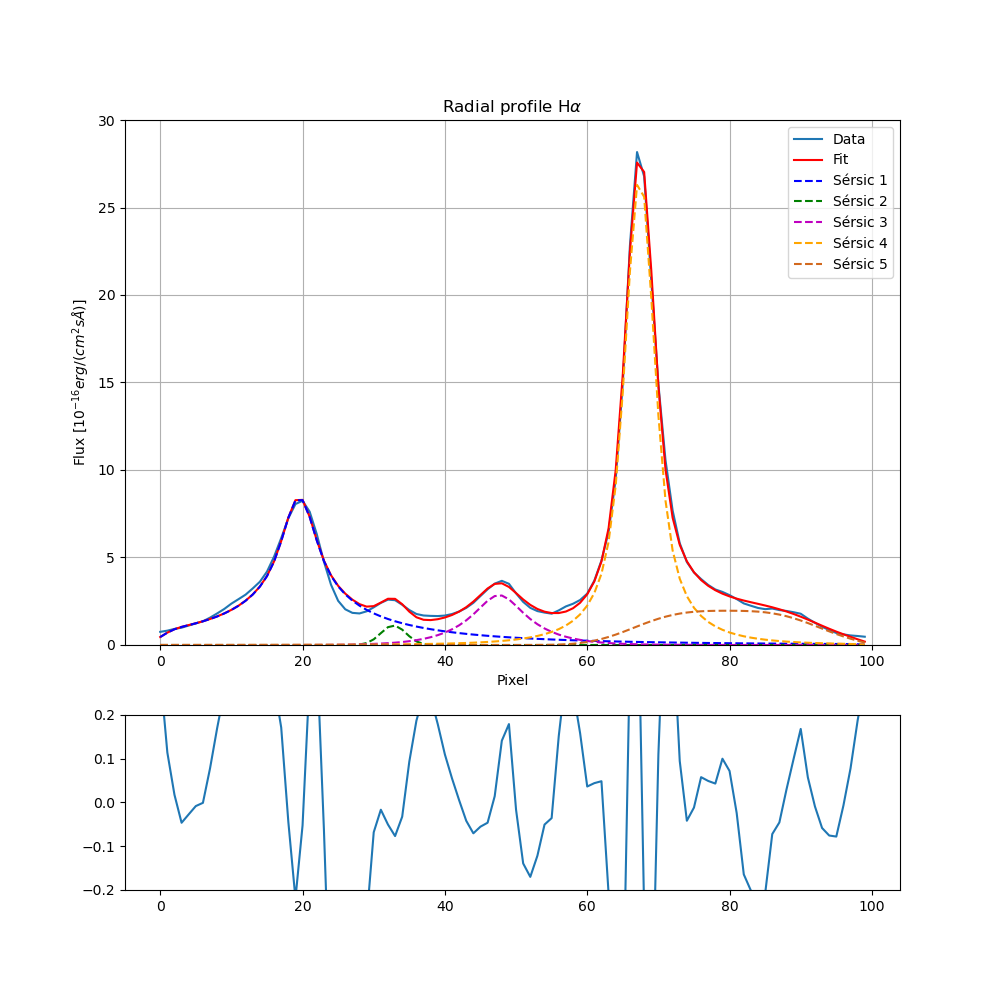

In [13]:
save_params_diff(best_params, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

plot_diff(x_axes, best_params, radial_profile_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_diff')

In [14]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HA, covariance_HA = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes, radial_profile_HA, p0=result.x, 
                                           sigma = real_errors_HA, bounds = bounds_list, maxfev= 10000)

print("Optimize parameters with curve fit:")

chi2_reduced_HA, dof_HA, chi2_HA = save_params(params_curve_HA, covariance_HA, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.1980, r_e=50.0000, n=2.4775, x_0=19.5000
Sérsic 2: I_e=1.2337, r_e=1.5051, n=0.1000, x_0=32.8000
Sérsic 3: I_e=0.7041, r_e=7.3942, n=0.9587, x_0=47.4308
Sérsic 4: I_e=1.9275, r_e=7.5590, n=2.1596, x_0=67.4651
Sérsic 5: I_e=1.2485, r_e=11.4767, n=0.3592, x_0=79.0000
[ 0.11165657 22.05639801  0.41029705  0.15712659 37.7266709  56.66362646
 10.51124534  0.34335849  0.38693621  3.04310483  0.3725861   0.31903662
  1.4936451   4.78903187  0.61170004  0.10999254  0.44056996  2.98648486
  0.09838877  5.14854249]
6.141010799458028


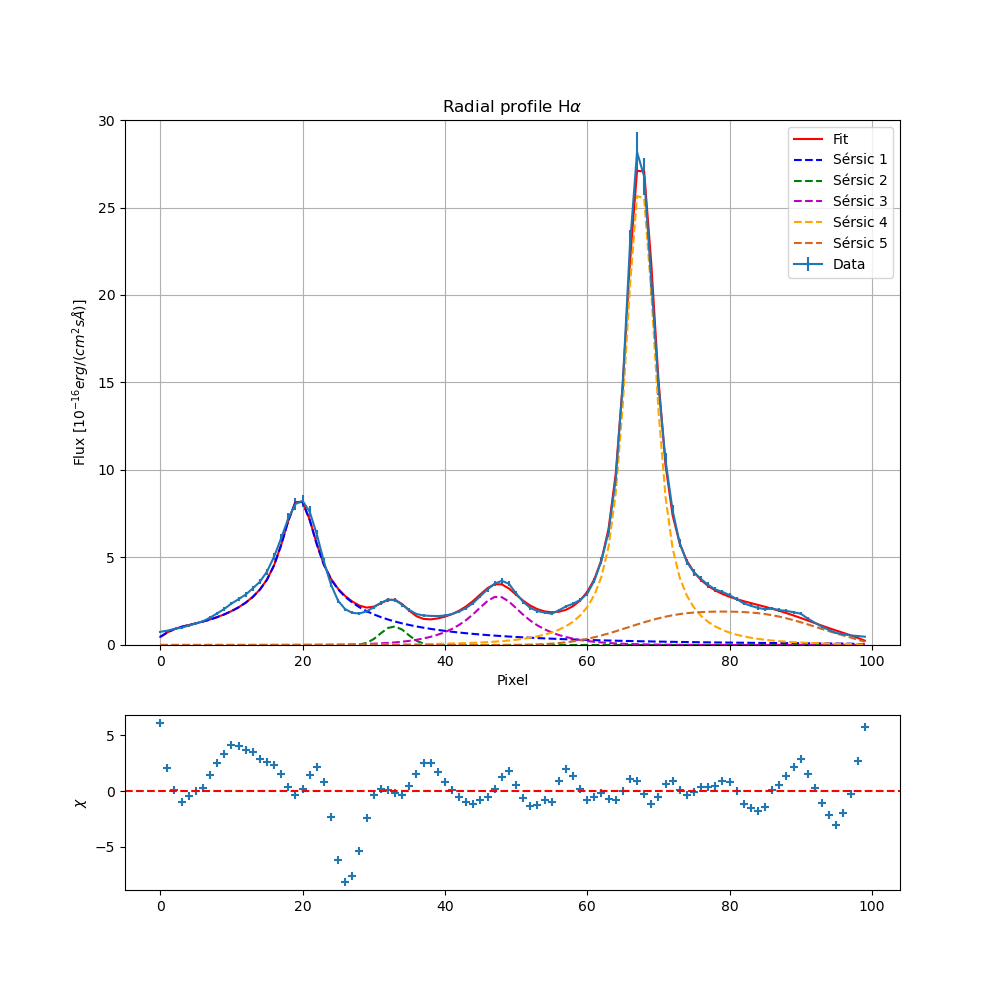

In [15]:
plot_curve(x_axes, params_curve_HA, radial_profile_HA, real_errors_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_curve')

In [16]:
fit_HA = pd.read_csv("Halpha_fit.csv", index_col=0)
x_0_HA = fit_HA.iloc[3].values
bounds = [
    (0, 20),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.8, x_0_HA[0]+1.8),   # x_0: circa la posizione di Halpha

    (0, 5),
    (0, 10),
    (0.1, 10),
    (x_0_HA[1]-1.2, x_0_HA[1]+1.2),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.2, x_0_HA[2]+1.2),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.8, x_0_HA[3]+1.8),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[4]-1.8, x_0_HA[4]+1.8)
]

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

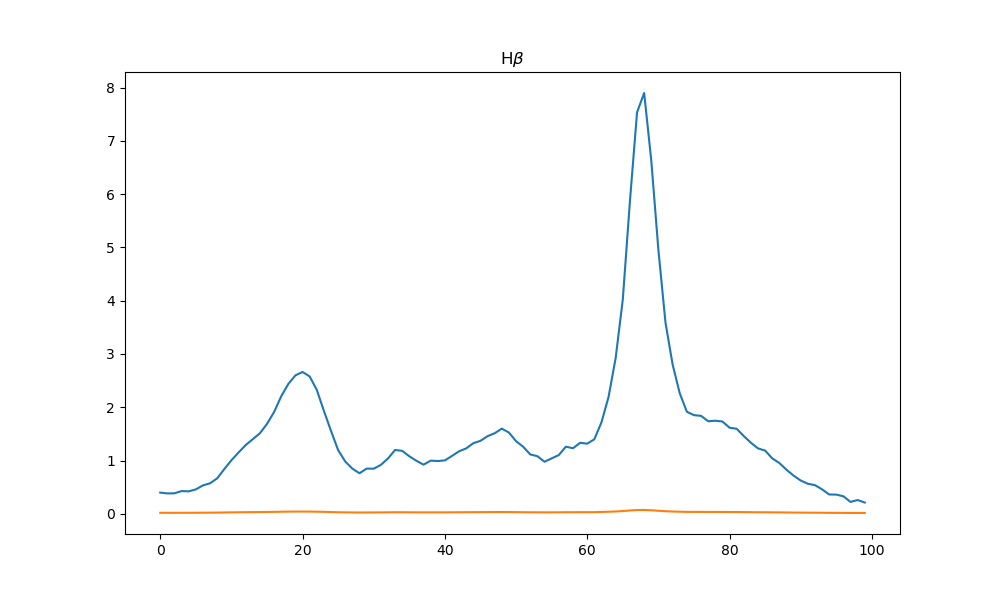

In [17]:
mask_HB = (wv > l_HB-8)*(wv < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))
real_errors_HB = np.sqrt(radial_profile_error_HB**2+(sky_err[2])**2+(0.04*radial_profile_HB)**2)

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [18]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 54718.7079798432
differential_evolution step 2: f(x)= 45947.417259582304
differential_evolution step 3: f(x)= 16357.586692433091
differential_evolution step 4: f(x)= 12663.068491475533
differential_evolution step 5: f(x)= 12663.068491475533
differential_evolution step 6: f(x)= 12663.068491475533
differential_evolution step 7: f(x)= 11555.25886492043
differential_evolution step 8: f(x)= 5923.245049520856
differential_evolution step 9: f(x)= 4264.420775647692
differential_evolution step 10: f(x)= 4264.420775647692
differential_evolution step 11: f(x)= 3725.553237632439
differential_evolution step 12: f(x)= 2826.032842164023
differential_evolution step 13: f(x)= 2826.032842164023
differential_evolution step 14: f(x)= 2826.032842164023
differential_evolution step 15: f(x)= 2826.032842164023
differential_evolution step 16: f(x)= 2076.451698505363
differential_evolution step 17: f(x)= 2076.451698505363
differential_evolution step 18: f(x)= 1922.9329739891

Sérsic 1: I_e=0.2233, r_e=24.9484, n=1.6252, x_0=19.1839
Sérsic 2: I_e=0.2301, r_e=0.4820, n=2.4448, x_0=33.8072
Sérsic 3: I_e=0.4702, r_e=10.4537, n=0.6585, x_0=47.4639
Sérsic 4: I_e=0.4775, r_e=6.8690, n=2.3494, x_0=67.6498
Sérsic 5: I_e=0.6260, r_e=13.0424, n=0.5959, x_0=77.2780


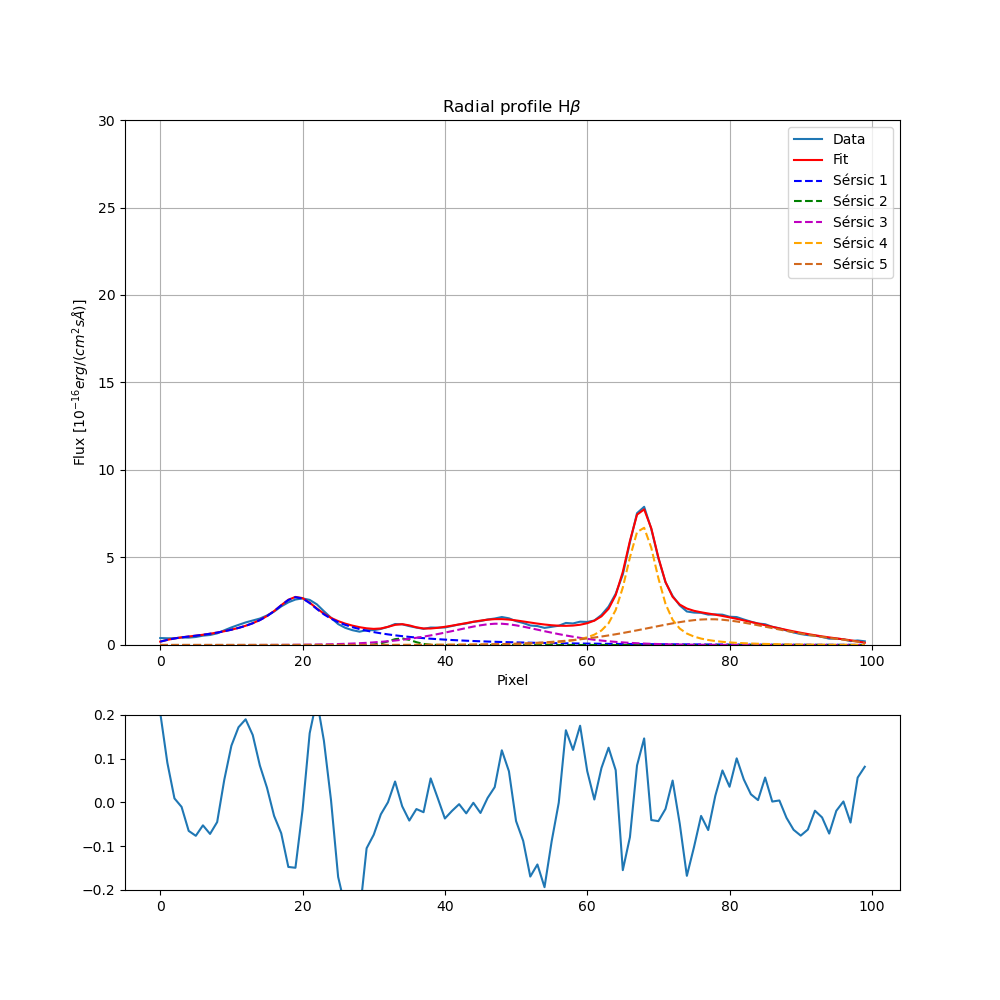

In [19]:
save_params_diff(best_params, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="HBeta", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_diff')

In [20]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HB, covariance_HB = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), 
                                           x_axes, radial_profile_HB, p0=result.x, sigma = real_errors_HB, bounds = bounds_list, maxfev = 10000)

print("Optimize parameters with curve fit:")
chi2_reduced_HB, dof_HB, chi2_HB = save_params(params_curve_HB, covariance_HB, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="Hbeta", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.2195, r_e=24.4390, n=1.6427, x_0=18.9216
Sérsic 2: I_e=0.2355, r_e=0.5611, n=2.4382, x_0=33.7955
Sérsic 3: I_e=0.4881, r_e=9.2317, n=0.6260, x_0=47.0305
Sérsic 4: I_e=0.2923, r_e=10.8646, n=2.6407, x_0=67.6092
Sérsic 5: I_e=0.5753, r_e=12.8719, n=0.6022, x_0=77.4343
[8.16826247e-02 7.57394499e+00 2.54850761e-01 1.99528249e-01
 3.27887813e+01 2.83380267e+01 1.80529131e+02 3.23758825e-01
 1.66791764e-01 6.51752639e+00 2.89065597e-01 8.26124732e-01
 2.25452239e+00 5.93391044e+01 8.19411002e+00 1.82086924e-02
 2.75757522e-01 3.50718662e+00 1.50770776e-01 2.67445121e+00]
2.7650428691163595


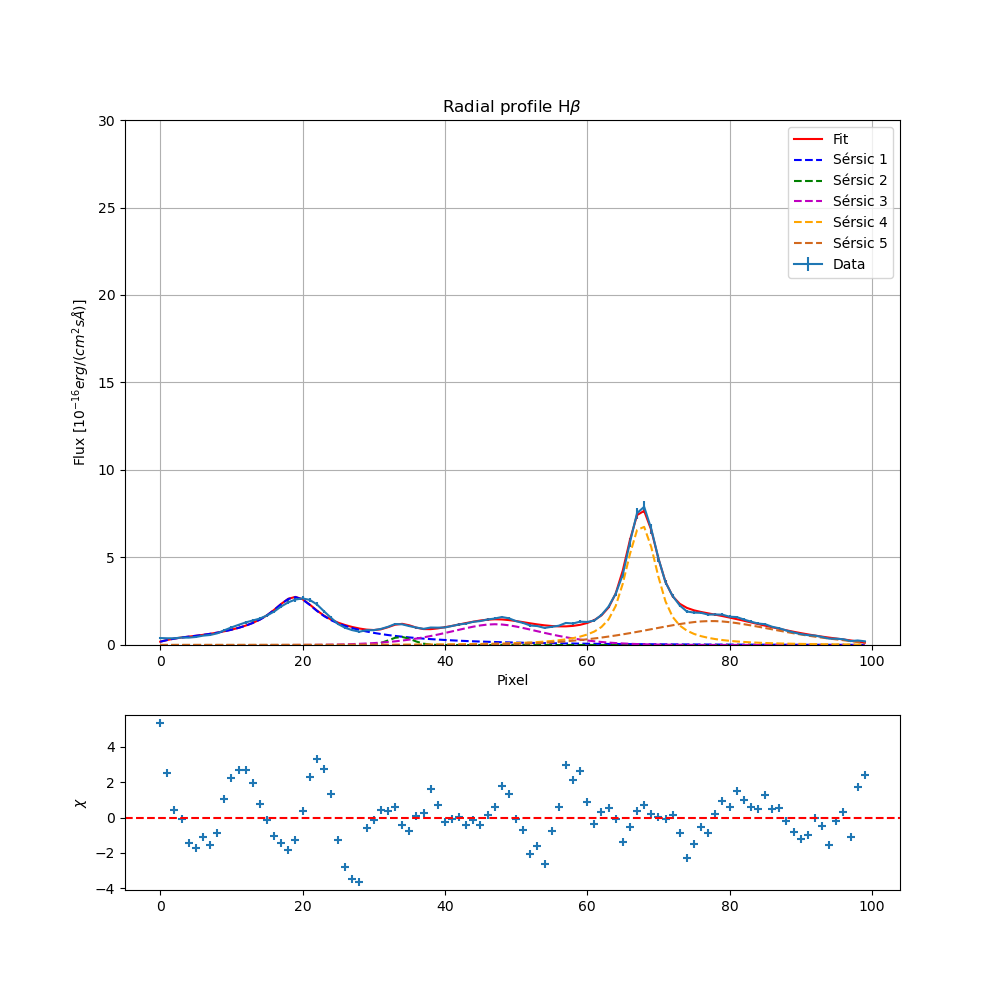

In [21]:
# Plots:
plot_curve(x_axes, params_curve_HB, radial_profile_HB, real_errors_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

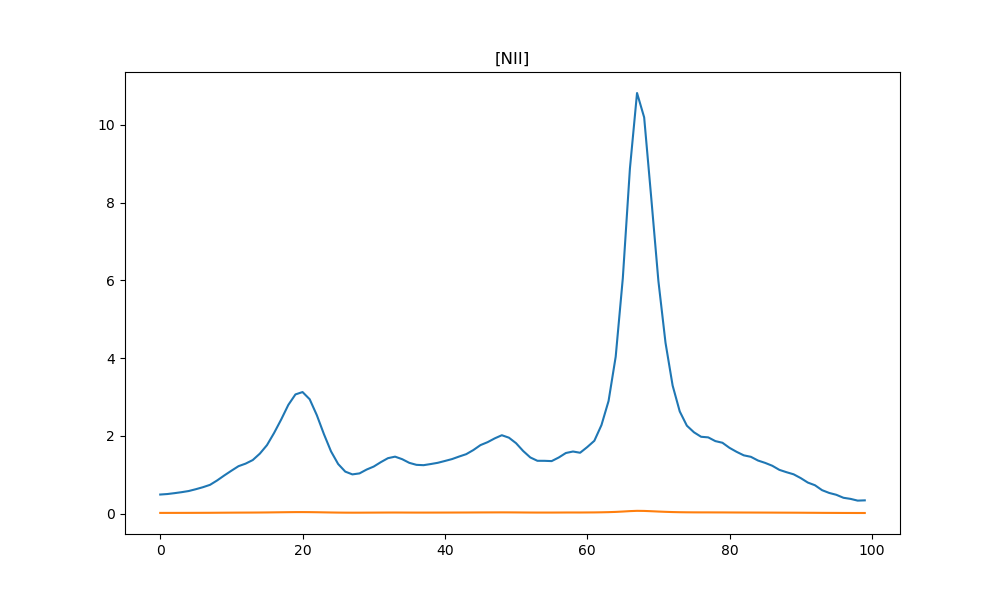

In [22]:
mask_NII = (wv > l_NII-8)*(wv < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))
real_errors_NII = np.sqrt(radial_profile_error_NII**2+(sky_err[2])**2+(0.04*radial_profile_NII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [98]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII, sigmas[2])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 40028.27630354745
differential_evolution step 2: f(x)= 40028.27630354745
differential_evolution step 3: f(x)= 40028.27630354745
differential_evolution step 4: f(x)= 22175.490273982745
differential_evolution step 5: f(x)= 22175.490273982745
differential_evolution step 6: f(x)= 2073.8212417093564
differential_evolution step 7: f(x)= 2073.8212417093564
differential_evolution step 8: f(x)= 2073.8212417093564
differential_evolution step 9: f(x)= 2073.8212417093564
differential_evolution step 10: f(x)= 2073.8212417093564
differential_evolution step 11: f(x)= 2073.8212417093564
differential_evolution step 12: f(x)= 1078.5065422268945
differential_evolution step 13: f(x)= 1060.388021749466
differential_evolution step 14: f(x)= 1060.388021749466
differential_evolution step 15: f(x)= 1060.388021749466
differential_evolution step 16: f(x)= 1060.388021749466
differential_evolution step 17: f(x)= 1060.388021749466
differential_evolution step 18: f(x)= 1060.38802

Sérsic 1: I_e=0.1164, r_e=49.1015, n=2.1091, x_0=19.3729
Sérsic 2: I_e=0.0141, r_e=8.3217, n=3.6413, x_0=33.2339
Sérsic 3: I_e=0.6158, r_e=8.9627, n=0.6113, x_0=47.0264
Sérsic 4: I_e=0.7101, r_e=7.3552, n=2.1774, x_0=67.3616
Sérsic 5: I_e=0.6494, r_e=13.8714, n=0.5424, x_0=77.9831


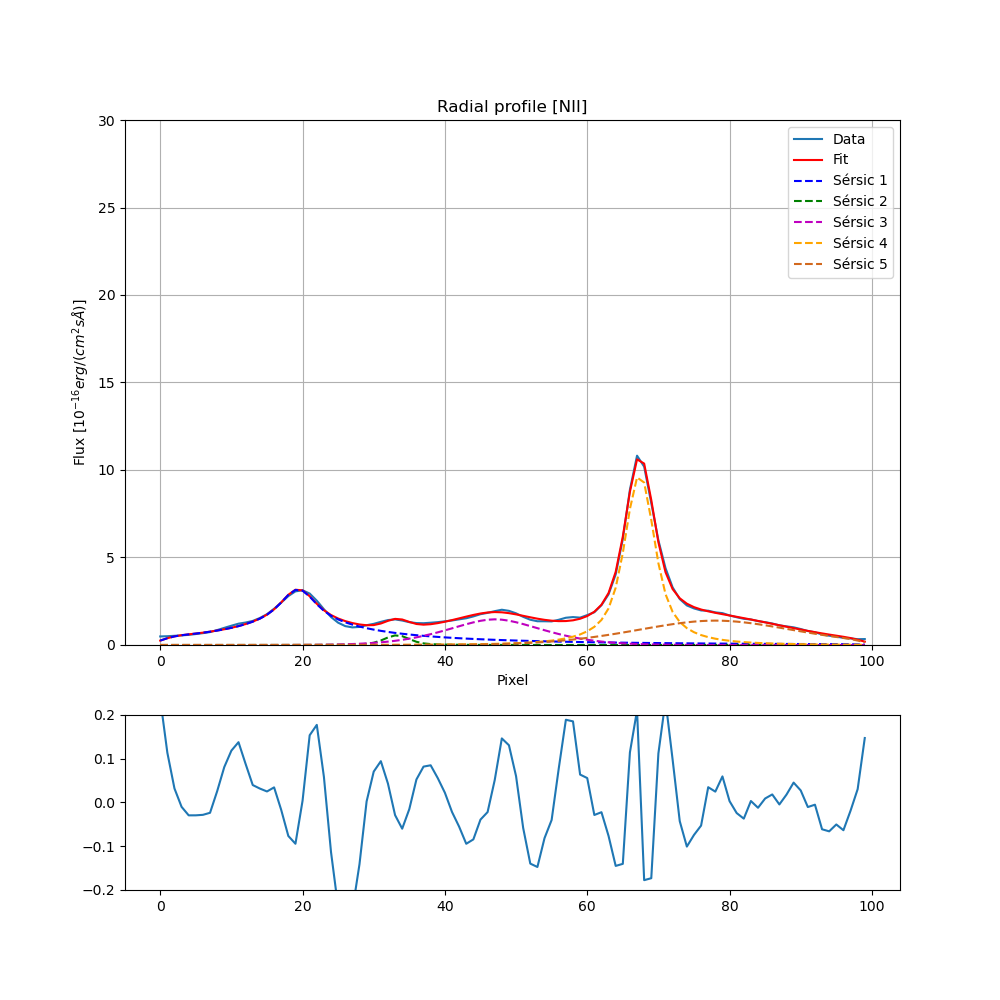

In [99]:
save_params_diff(best_params, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_diff')

In [25]:
df = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC4904/FORS2.2022-02-07T08_36_57.209/Fit/Diff_params/NII_fit_diff.csv", index_col=0)
initial_guesses = np.concatenate([
    df['Component 1'].values,  # [I_e, r_e, n, x_0] per Component 1
    df['Component 2'].values,  # [I_e, r_e, n, x_0] per Component 2
    df['Component 3'].values,   # [I_e, r_e, n, x_0] per Component 3
    df['Component 4'].values,
    df['Component 5'].values
])
print(df)

     Component 1  Component 2  Component 3  Component 4  Component 5
I_e       0.1164       0.0141       0.6158       0.7101       0.6494
r_e      49.1015       8.3217       8.9627       7.3552      13.8714
n         2.1091       3.6413       0.6113       2.1774       0.5424
x_0      19.3729      33.2339      47.0264      67.3616      77.9831


In [26]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_NII, covariance_NII = curve_fit(lambda x, *params: model_convolved(x, sigmas[2], *params), x_axes, radial_profile_NII, 
                                             p0=result.x, sigma = real_errors_NII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_NII, dof_NII, chi2_NII = save_params(params_curve_NII, covariance_NII, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.1179, r_e=47.9646, n=2.0928, x_0=19.1118
Sérsic 2: I_e=0.4904, r_e=2.4904, n=0.1145, x_0=33.3205
Sérsic 3: I_e=0.6214, r_e=8.2820, n=0.5942, x_0=46.7785
Sérsic 4: I_e=0.3357, r_e=12.1983, n=2.7866, x_0=67.3957
Sérsic 5: I_e=0.6786, r_e=13.5896, n=0.4803, x_0=77.2001
[1.15575465e-01 3.61462559e+01 7.61780215e-01 2.16841212e-02
 1.01833081e+00 1.00871386e+01 1.35635236e+00 3.47160068e-01
 1.70229341e-01 2.44774054e+00 1.67593184e-01 5.39968935e-01
 1.10166009e+00 3.36181147e+01 2.40837537e+00 7.16712407e-02
 4.12186628e-01 4.24371269e+00 9.10235653e-02 6.21112361e+00]
2.318567355529165


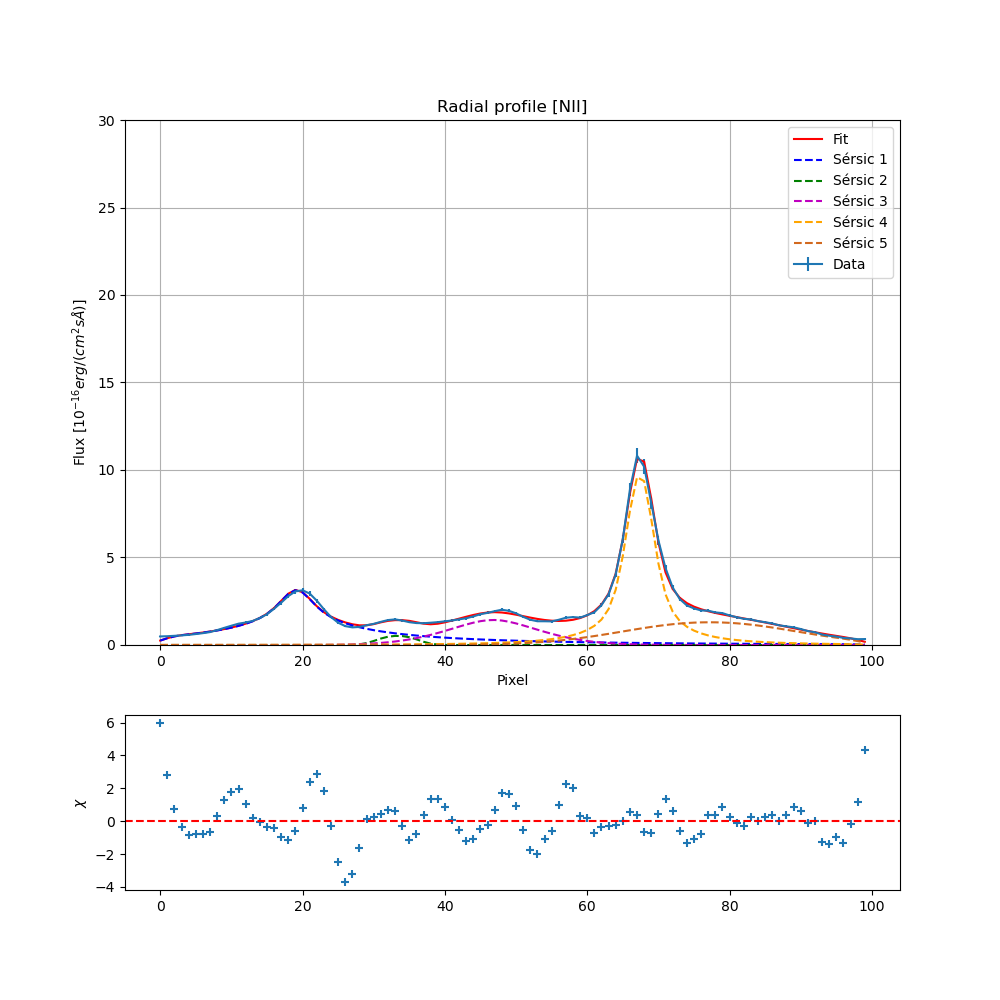

In [27]:
plot_curve(x_axes, params_curve_NII, radial_profile_NII, real_errors_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_curve')

## [SII]

Text(0.5, 1.0, '[SII]')

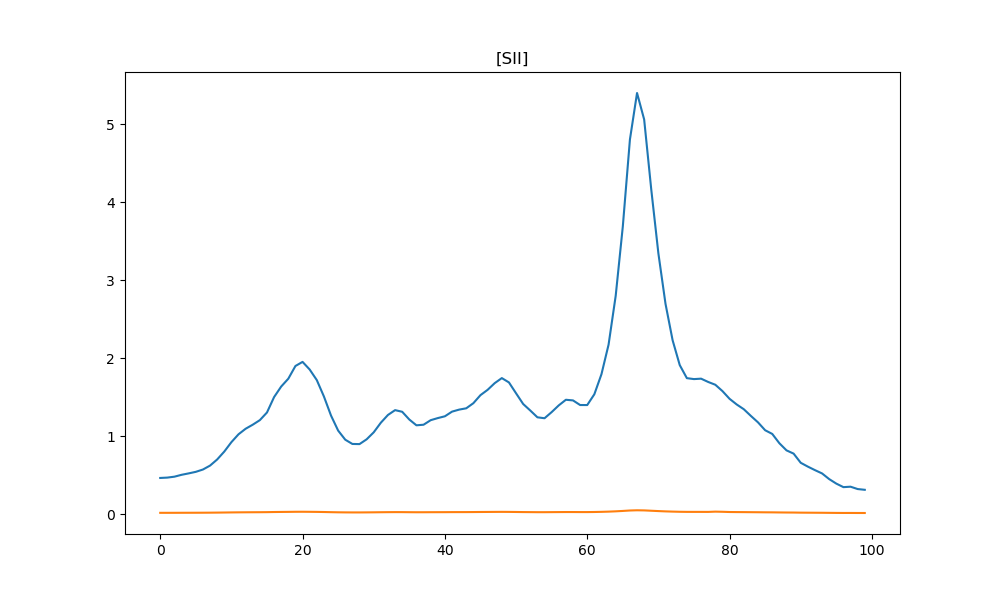

In [28]:
mask_SII = (wv > l_SII-8)*(wv < l_SII+8)
x_axes = np.arange(0, 100, 1)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))
real_errors_SII = np.sqrt(radial_profile_error_SII**2+(sky_err[2])**2+(0.04*radial_profile_SII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [103]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII, sigmas[3])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 228312.47680563456
differential_evolution step 2: f(x)= 16399.616416708708
differential_evolution step 3: f(x)= 16399.616416708708
differential_evolution step 4: f(x)= 6846.837926793377
differential_evolution step 5: f(x)= 6846.837926793377
differential_evolution step 6: f(x)= 4621.031160317877
differential_evolution step 7: f(x)= 4621.031160317877
differential_evolution step 8: f(x)= 2458.9710748888065
differential_evolution step 9: f(x)= 2458.9710748888065
differential_evolution step 10: f(x)= 2458.9710748888065
differential_evolution step 11: f(x)= 2458.9710748888065
differential_evolution step 12: f(x)= 1553.8387495280147
differential_evolution step 13: f(x)= 1201.4486580621135
differential_evolution step 14: f(x)= 1201.4486580621135
differential_evolution step 15: f(x)= 835.6750802038082
differential_evolution step 16: f(x)= 81.53528671226198
differential_evolution step 17: f(x)= 81.53528671226198
differential_evolution step 18: f(x)= 81.535286

Sérsic 1: I_e=0.1309, r_e=45.5998, n=1.6517, x_0=19.2536
Sérsic 2: I_e=0.0898, r_e=2.2272, n=1.8040, x_0=33.0952
Sérsic 3: I_e=0.4871, r_e=10.1871, n=0.6028, x_0=47.0294
Sérsic 4: I_e=0.2680, r_e=12.5033, n=2.1317, x_0=67.1710
Sérsic 5: I_e=0.3742, r_e=15.7238, n=0.7520, x_0=78.7381


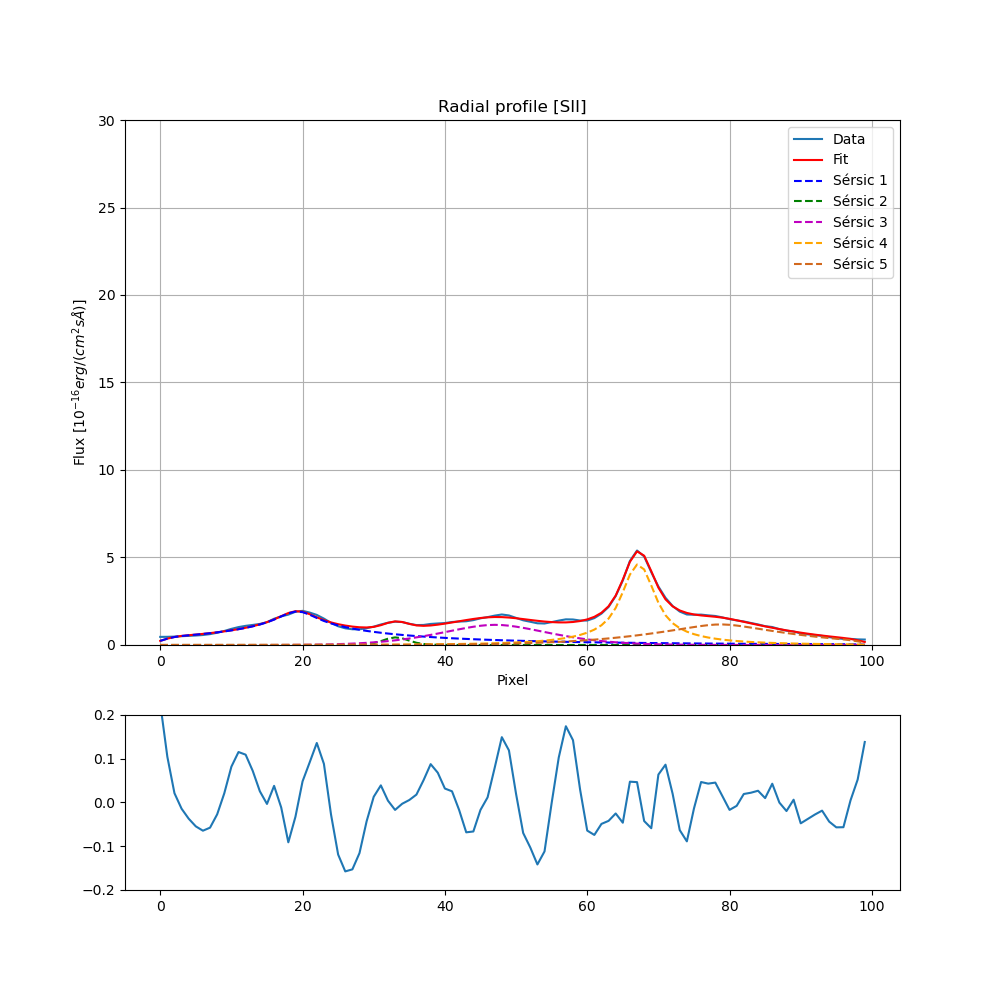

In [104]:
save_params_diff(best_params, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_diff')

In [31]:
df = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC4904/FORS2.2022-02-07T08_36_57.209/Fit/Diff_params/SII_fit_diff.csv", index_col=0)
initial_guesses = np.concatenate([
    df['Component 1'].values,  # [I_e, r_e, n, x_0] per Component 1
    df['Component 2'].values,  # [I_e, r_e, n, x_0] per Component 2
    df['Component 3'].values,   # [I_e, r_e, n, x_0] per Component 3
    df['Component 4'].values,
    df['Component 5'].values
])
print(df)

     Component 1  Component 2  Component 3  Component 4  Component 5
I_e       0.1309       0.0898       0.4871       0.2680       0.3742
r_e      45.5998       2.2272      10.1871      12.5033      15.7238
n         1.6517       1.8040       0.6028       2.1317       0.7520
x_0      19.2536      33.0952      47.0294      67.1710      78.7381


In [32]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_SII, covariance_SII = curve_fit(lambda x, *params: model_convolved(x, sigmas[3], *params), x_axes, 
                                             radial_profile_SII, p0=result.x, sigma = real_errors_SII, bounds = bounds_list)

print("Optimize parameters with curve fit:")
chi2_reduced_SII, dof_SII, chi2_SII = save_params(params_curve_SII, covariance_SII, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.1119, r_e=50.0000, n=1.7506, x_0=19.1272
Sérsic 2: I_e=0.4700, r_e=1.7652, n=0.1427, x_0=33.1098
Sérsic 3: I_e=0.5152, r_e=8.6228, n=0.5223, x_0=46.5626
Sérsic 4: I_e=0.0969, r_e=33.2776, n=2.8200, x_0=67.2022
Sérsic 5: I_e=0.2900, r_e=14.3861, n=0.8112, x_0=79.3544
[5.07760986e-02 2.36247373e+01 2.90869641e-01 1.97957432e-01
 1.89958617e-01 8.94199518e+00 2.82871547e+00 3.23730470e-01
 9.90914362e-02 3.28635142e+00 1.73245264e-01 6.33019297e-01
 3.06148797e-01 9.88265674e+01 2.12586679e+00 9.86668746e-02
 1.08612565e-01 7.33830250e+00 1.83006215e-01 1.05794973e+00]
1.9658749748087807


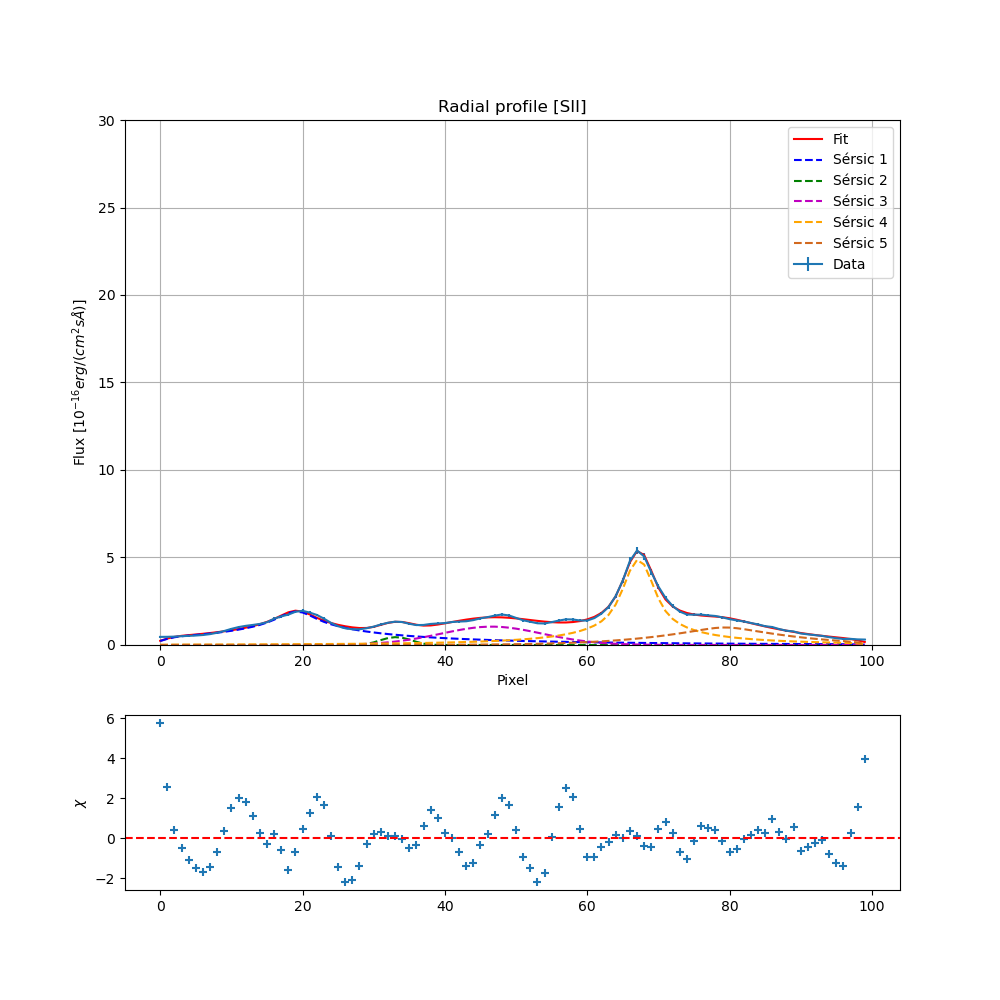

In [33]:
# Plots:
plot_curve(x_axes, params_curve_SII, radial_profile_SII, real_errors_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

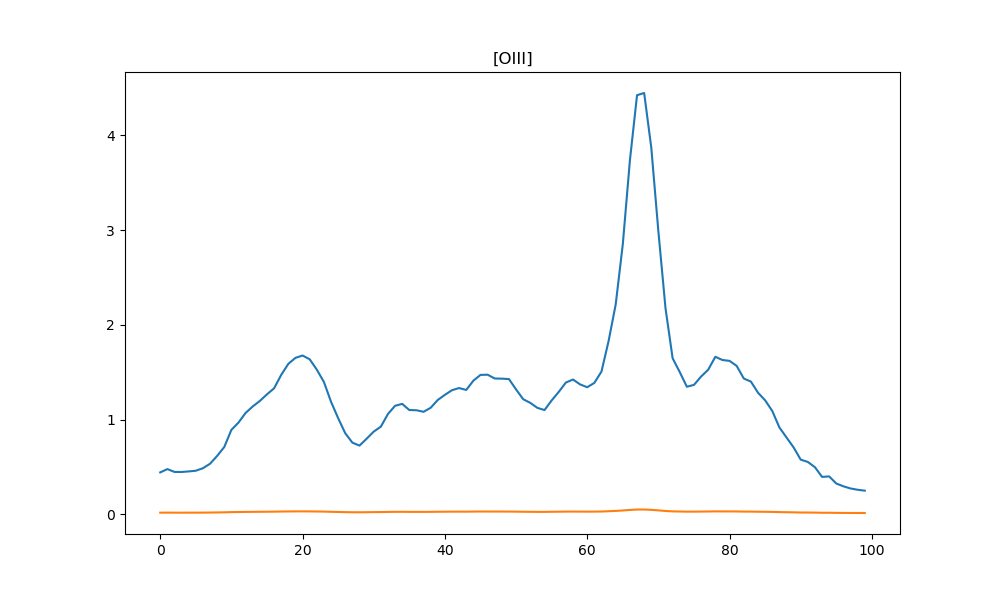

In [34]:
mask_OIII = (wv > l_OIII-8)*(wv < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))
real_errors_OIII = np.sqrt(radial_profile_error_OIII**2+(sky_err[2])**2+(0.04*radial_profile_OIII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [126]:
# Bounds:
bounds =[
    (0, 20),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.8, x_0_HA[0]+1.8),   # x_0: circa la posizione di Halpha

    (0, 0.15),
    (0, 30),
    (0.1, 10),
    (x_0_HA[1]-1.2, x_0_HA[1]+1.2),

    (0, 20),
    (0, 30),
    (0.1, 10),
    (x_0_HA[2]-1.2, x_0_HA[2]+1.2),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.8, x_0_HA[3]+1.8),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[4]-1.8, x_0_HA[4]+1.8)
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII, sigmas[4])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 170161.8671948213
differential_evolution step 2: f(x)= 18358.50094990488
differential_evolution step 3: f(x)= 16566.818513585844
differential_evolution step 4: f(x)= 6772.208803714817
differential_evolution step 5: f(x)= 6695.756940641743
differential_evolution step 6: f(x)= 6695.756940641743
differential_evolution step 7: f(x)= 5566.641100252227
differential_evolution step 8: f(x)= 1131.222931951838
differential_evolution step 9: f(x)= 1131.222931951838
differential_evolution step 10: f(x)= 1131.222931951838
differential_evolution step 11: f(x)= 685.8613987841582
differential_evolution step 12: f(x)= 439.64774044410683
differential_evolution step 13: f(x)= 439.64774044410683
differential_evolution step 14: f(x)= 439.64774044410683
differential_evolution step 15: f(x)= 439.64774044410683
differential_evolution step 16: f(x)= 439.64774044410683
differential_evolution step 17: f(x)= 147.20893285863664
differential_evolution step 18: f(x)= 147.20893285

Sérsic 1: I_e=0.2028, r_e=29.3243, n=1.3271, x_0=19.1081
Sérsic 2: I_e=0.0925, r_e=0.5448, n=2.8155, x_0=33.1980
Sérsic 3: I_e=0.7974, r_e=10.2539, n=0.2585, x_0=48.7338
Sérsic 4: I_e=0.2159, r_e=10.6450, n=2.3640, x_0=67.5089
Sérsic 5: I_e=0.3863, r_e=12.3974, n=0.8708, x_0=80.4535


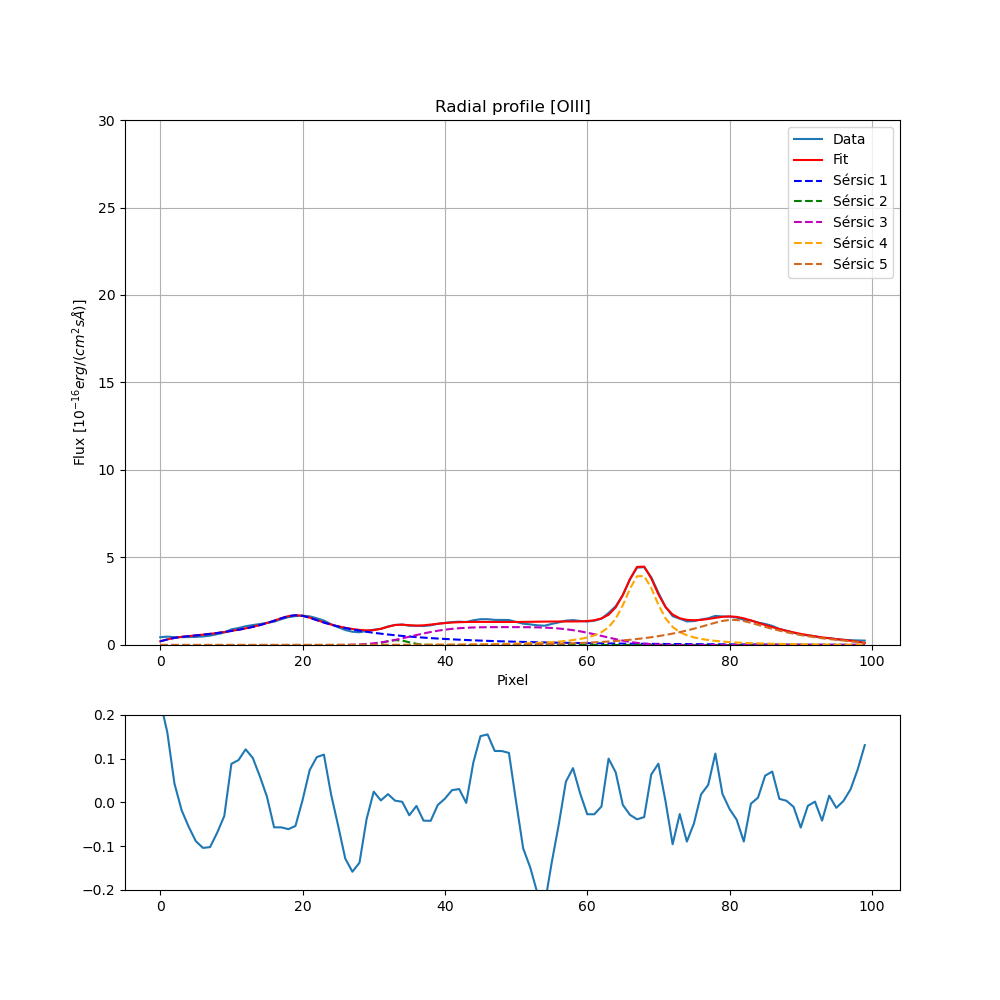

In [127]:
save_params_diff(best_params, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_diff')

In [35]:
df = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC4904/FORS2.2022-02-07T08_36_57.209/Fit/Diff_params/OIII_fit_diff.csv", index_col=0)
initial_guesses = np.concatenate([
    df['Component 1'].values,  # [I_e, r_e, n, x_0] per Component 1
    df['Component 2'].values,  # [I_e, r_e, n, x_0] per Component 2
    df['Component 3'].values,   # [I_e, r_e, n, x_0] per Component 3
    df['Component 4'].values,
    df['Component 5'].values
])
print(df)

     Component 1  Component 2  Component 3  Component 4  Component 5
I_e       0.2028       0.0925       0.7974       0.2159       0.3863
r_e      29.3243       0.5448      10.2539      10.6450      12.3974
n         1.3271       2.8155       0.2585       2.3640       0.8708
x_0      19.1081      33.1980      48.7338      67.5089      80.4535


In [36]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_OIII, covariance_OIII = curve_fit(lambda x, *params: model_convolved(x, sigmas[4], *params), x_axes, radial_profile_OIII, 
                                               p0=result.x, sigma = real_errors_OIII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_OIII, dof_OIII, chi2_OIII = save_params(params_curve_OIII, covariance_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.1814, r_e=31.3501, n=1.4044, x_0=18.9849
Sérsic 2: I_e=0.8607, r_e=0.6202, n=0.1320, x_0=32.7494
Sérsic 3: I_e=0.8809, r_e=9.9433, n=0.2082, x_0=48.6308
Sérsic 4: I_e=0.7533, r_e=4.4838, n=1.4037, x_0=67.4213
Sérsic 5: I_e=0.3820, r_e=13.5365, n=0.9233, x_0=80.1722
[7.00913498e-02 1.07244397e+01 2.43462844e-01 2.26164607e-01
 1.80017458e+02 5.46693725e+02 3.60754550e+02 4.68553109e-01
 1.52045622e-01 1.25039689e+00 1.18788420e-01 1.16477258e+00
 6.61843101e-01 2.69096290e+00 6.69225255e-01 1.74552665e-01
 9.61002395e-02 1.96607445e+00 1.43555845e-01 5.92430123e-01]
2.5470816334205635


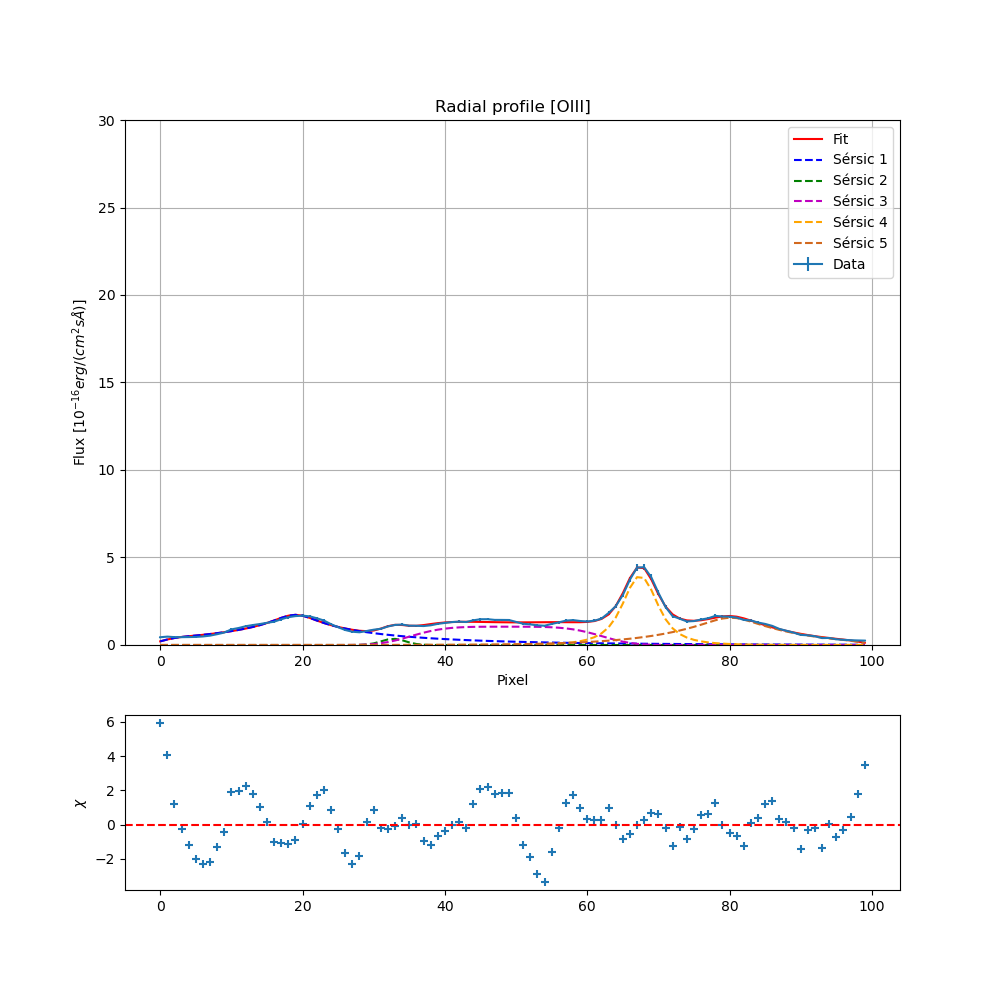

In [37]:
plot_curve(x_axes, params_curve_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_curve')

In [38]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

## Continuum 1

Text(0.5, 1.0, 'Continuum 1')

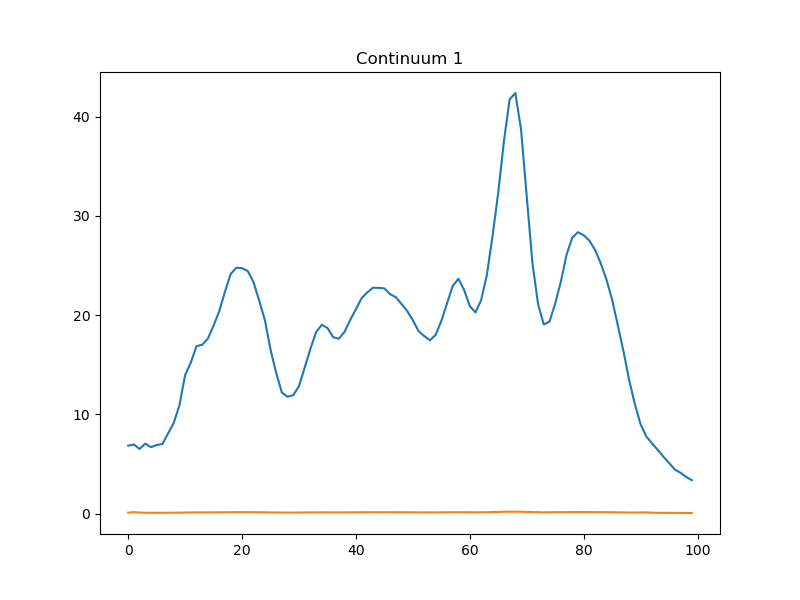

In [39]:
mask_continuum_1 = (wv > 4400)*(wv < 4650)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.sum(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))
real_errors_c1 = np.sqrt(radial_profile_error_continuum_1**2+(sky_err[2])**2+(0.04*radial_profile_continuum_1)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

In [15]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_1, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 109129.76027003261
differential_evolution step 2: f(x)= 5109.64499676007
differential_evolution step 3: f(x)= 5109.64499676007
differential_evolution step 4: f(x)= 5109.64499676007
differential_evolution step 5: f(x)= 5109.64499676007
differential_evolution step 6: f(x)= 5109.64499676007
differential_evolution step 7: f(x)= 5109.64499676007
differential_evolution step 8: f(x)= 5109.64499676007
differential_evolution step 9: f(x)= 5109.64499676007
differential_evolution step 10: f(x)= 5109.64499676007
differential_evolution step 11: f(x)= 5109.64499676007
differential_evolution step 12: f(x)= 5109.64499676007
differential_evolution step 13: f(x)= 2951.8799385264474
differential_evolution step 14: f(x)= 2951.8799385264474
differential_evolution step 15: f(x)= 2951.8799385264474
differential_evolution step 16: f(x)= 2951.8799385264474
differential_evolution step 17: f(x)= 2951.8799385264474
differential_evolution step 18: f(x)= 2951.8799385264474
diffe

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_7440\3739267833.py:9: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution:
Sérsic 1: I_e=8.0202, r_e=4.0821, n=0.4201, x_0=19.5000
Sérsic 2: I_e=0.1000, r_e=36.5576, n=0.1236, x_0=32.1309
Sérsic 3: I_e=5.6509, r_e=49.9952, n=0.8125, x_0=45.0004
Sérsic 4: I_e=1.5880, r_e=14.9008, n=2.1841, x_0=67.5596
Sérsic 5: I_e=14.4539, r_e=4.1905, n=0.1787, x_0=81.3318
Chi quadro minimo: 291.5363026639174
False


In [40]:
def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 30)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 30)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

Sérsic 1: I_e=8.0202, r_e=4.0821, n=0.4201, x_0=19.5000
Sérsic 2: I_e=0.1000, r_e=36.5576, n=0.1236, x_0=32.1309
Sérsic 3: I_e=5.6509, r_e=49.9952, n=0.8125, x_0=45.0004
Sérsic 4: I_e=1.5880, r_e=14.9008, n=2.1841, x_0=67.5596
Sérsic 5: I_e=14.4539, r_e=4.1905, n=0.1787, x_0=81.3318


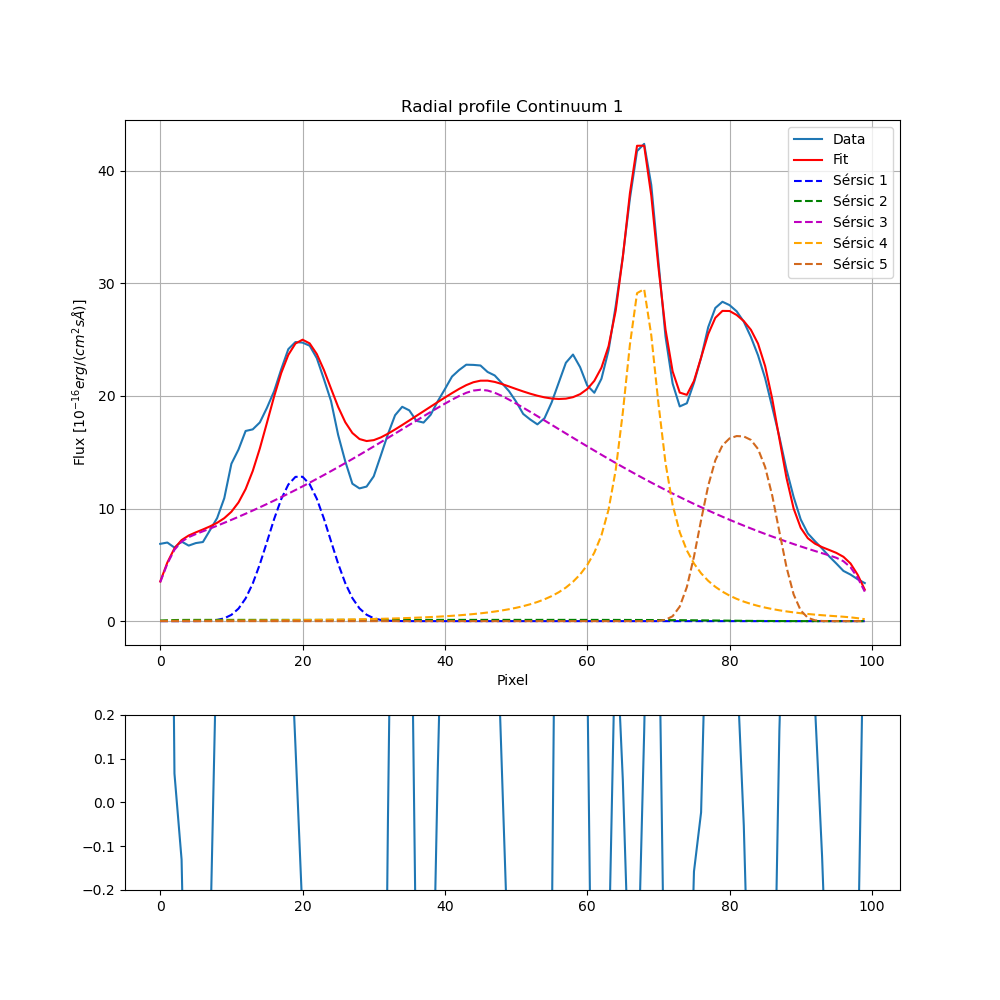

In [21]:
save_params_diff(best_params, radial_profile_continuum_1, real_errors_c1, sigmas[1],
    x_axes, n_component, line_name="Continuum_1", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_diff')

In [42]:
df = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC4904/FORS2.2022-02-07T08_36_57.209/Fit/Diff_params/Continuum_1_fit_diff.csv", index_col=0)
initial_guesses = np.concatenate([
    df['Component 1'].values,  # [I_e, r_e, n, x_0] per Component 1
    df['Component 2'].values,  # [I_e, r_e, n, x_0] per Component 2
    df['Component 3'].values,   # [I_e, r_e, n, x_0] per Component 3
    df['Component 4'].values,
    df['Component 5'].values
])
print(df)

     Component 1  Component 2  Component 3  Component 4  Component 5
I_e       8.0202       0.1000       5.6509       1.5880      14.4539
r_e       4.0821      36.5576      49.9952      14.9008       4.1905
n         0.4201       0.1236       0.8125       2.1841       0.1787
x_0      19.5000      32.1309      45.0004      67.5596      81.3318


In [43]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))

params_curve_continuum_1, covariance_continuum_1 = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), x_axes,
                                                             radial_profile_continuum_1, p0=result.x, sigma = real_errors_c1, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_1, dof_continuum_1, chi2_continuum_1 = save_params(params_curve_continuum_1, covariance_continuum_1, 
                                                                          radial_profile_continuum_1, real_errors_c1, sigmas[1],
                                                                          x_axes, n_component, line_name="Continuum_1", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=2.3584, r_e=35.9331, n=1.5037, x_0=19.2430
Sérsic 2: I_e=0.7695, r_e=0.1132, n=3.7020, x_0=33.8912
Sérsic 3: I_e=13.2923, r_e=10.6168, n=0.2136, x_0=48.6308
Sérsic 4: I_e=5.7159, r_e=5.9045, n=1.4120, x_0=67.4046
Sérsic 5: I_e=4.9583, r_e=14.4046, n=1.1515, x_0=80.5170
[1.27131152e+00 1.65506551e+01 3.47175461e-01 3.46922348e-01
 2.37777455e+05 1.36779543e+04 2.36695848e+05 1.09133119e+01
 1.45857636e+00 2.07551246e+00 6.31164990e-02 2.72824297e+00
 7.03779377e+00 5.65370656e+00 9.14681226e-01 3.78437861e-01
 1.55850593e+00 2.56569002e+00 1.99201959e-01 4.94110907e-01]
8.278250122704629


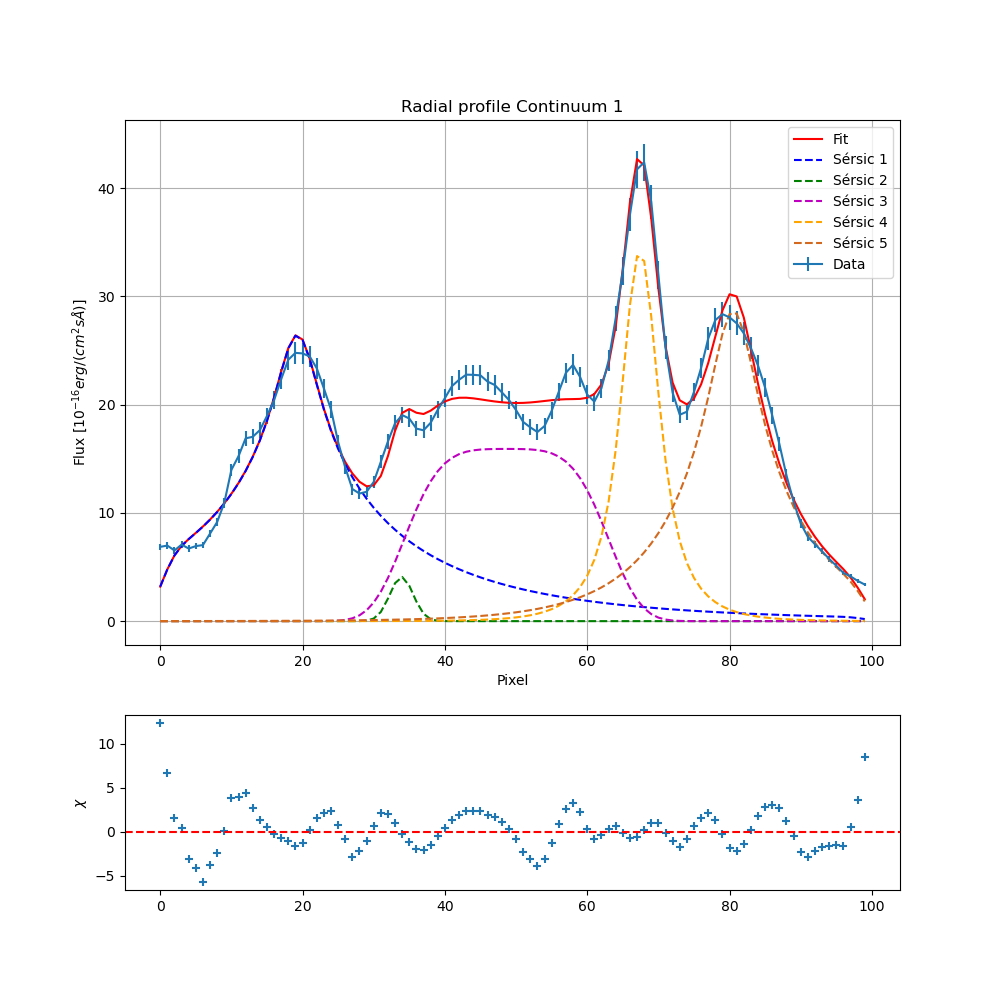

In [44]:
# Plots:
plot_curve(x_axes, params_curve_continuum_1, radial_profile_continuum_1, real_errors_c1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_curve')

## Continuum 2 

Text(0.5, 1.0, 'Continuum 2')

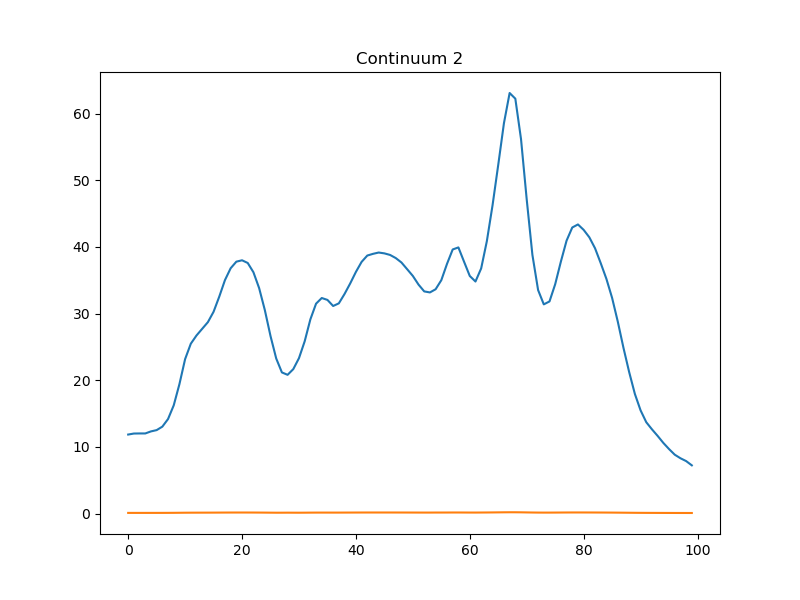

In [45]:
mask_continuum_2 = (wv > 5100)*(wv < 5550)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.sum(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))
real_errors_c2 = np.sqrt(radial_profile_error_continuum_2**2+(sky_err[2])**2+(0.04*radial_profile_continuum_2)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

In [25]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_2, sigmas[5])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 25690.021981759048
differential_evolution step 2: f(x)= 17095.07514803728
differential_evolution step 3: f(x)= 16964.586001723543
differential_evolution step 4: f(x)= 13429.582084831361
differential_evolution step 5: f(x)= 13429.582084831361
differential_evolution step 6: f(x)= 4988.609089812502
differential_evolution step 7: f(x)= 4988.609089812502
differential_evolution step 8: f(x)= 4988.609089812502
differential_evolution step 9: f(x)= 4988.609089812502
differential_evolution step 10: f(x)= 4988.609089812502
differential_evolution step 11: f(x)= 4988.609089812502
differential_evolution step 12: f(x)= 4058.595625383172
differential_evolution step 13: f(x)= 4058.595625383172
differential_evolution step 14: f(x)= 3801.457681002412
differential_evolution step 15: f(x)= 3801.457681002412
differential_evolution step 16: f(x)= 3801.457681002412
differential_evolution step 17: f(x)= 3801.457681002412
differential_evolution step 18: f(x)= 3401.7624316874

Sérsic 1: I_e=10.9552, r_e=3.9388, n=0.3834, x_0=19.5000
Sérsic 2: I_e=0.1000, r_e=46.6544, n=0.3659, x_0=32.1769
Sérsic 3: I_e=10.2376, r_e=50.0000, n=0.7960, x_0=45.4644
Sérsic 4: I_e=1.9133, r_e=18.3669, n=2.1765, x_0=67.3368
Sérsic 5: I_e=18.4550, r_e=4.1229, n=0.2086, x_0=81.1280


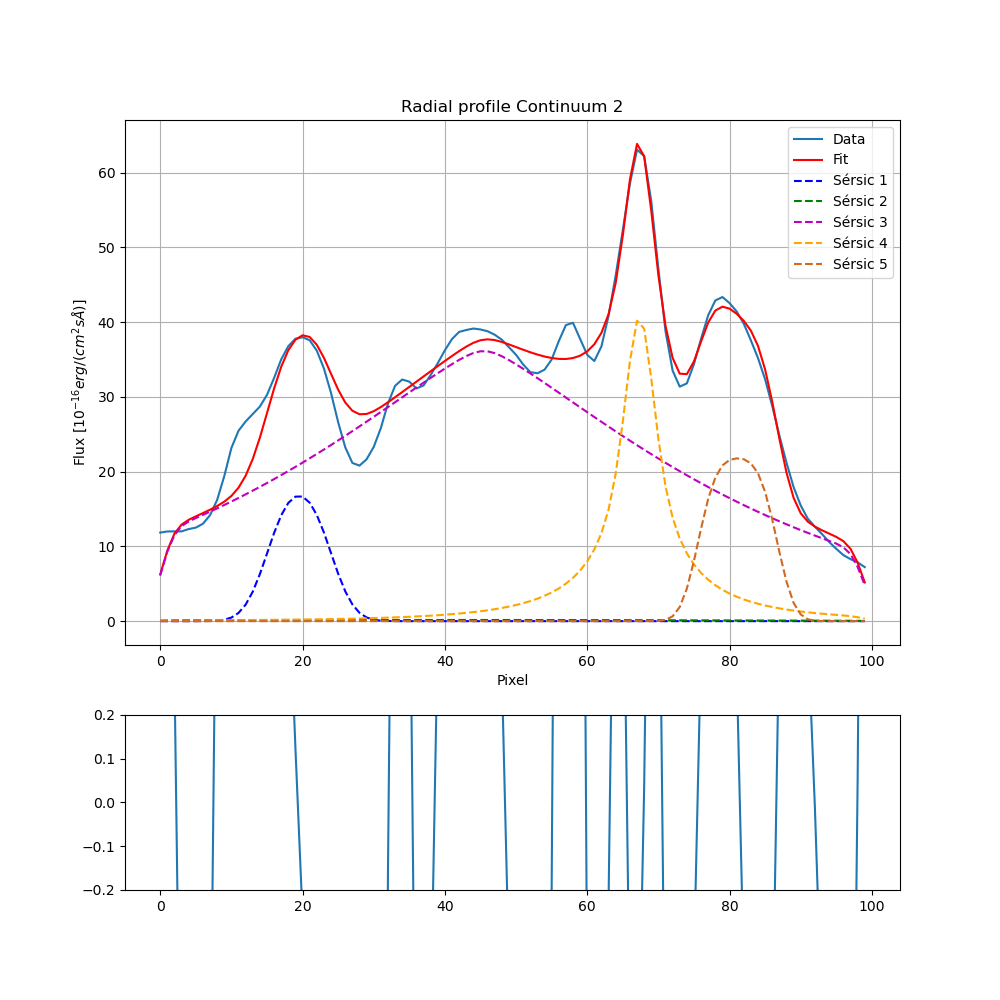

In [28]:
save_params_diff(best_params, radial_profile_continuum_2, real_errors_c2, sigmas[-1],
    x_axes, n_component, line_name="Continuum_2", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_2, sigmas[-1], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_diff')

In [46]:
df = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC4904/FORS2.2022-02-07T08_36_57.209/Fit/Diff_params/Continuum_2_fit_diff.csv", index_col=0)
initial_guesses = np.concatenate([
    df['Component 1'].values,  # [I_e, r_e, n, x_0] per Component 1
    df['Component 2'].values,  # [I_e, r_e, n, x_0] per Component 2
    df['Component 3'].values,   # [I_e, r_e, n, x_0] per Component 3
    df['Component 4'].values,
    df['Component 5'].values
])
print(df)

     Component 1  Component 2  Component 3  Component 4  Component 5
I_e      10.9552       0.1000      10.2376       1.9133      18.4550
r_e       3.9388      46.6544      50.0000      18.3669       4.1229
n         0.3834       0.3659       0.7960       2.1765       0.2086
x_0      19.5000      32.1769      45.4644      67.3368      81.1280


In [47]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_2, covariance_continuum_2 = curve_fit(lambda x, *params: model_convolved(x, sigmas[-1], *params), x_axes, radial_profile_continuum_2, p0=result.x, 
                                                             sigma = real_errors_c2, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_2, dof_continuum_2, chi2_continuum_2 = save_params(params_curve_continuum_2, covariance_continuum_2, radial_profile_continuum_2,
                                                                          real_errors_c2, sigmas[-1], x_axes, n_component, line_name="Continuum_2", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=3.1788, r_e=48.8521, n=1.5424, x_0=19.2006
Sérsic 2: I_e=1.9195, r_e=0.7041, n=2.7809, x_0=33.0990
Sérsic 3: I_e=20.0000, r_e=10.5336, n=0.2636, x_0=48.4070
Sérsic 4: I_e=4.6381, r_e=10.1559, n=1.7072, x_0=67.2038
Sérsic 5: I_e=5.0207, r_e=21.1522, n=1.3360, x_0=80.2997
[2.04185762e+00 2.86639864e+01 3.97652894e-01 4.09351723e-01
 9.92401400e+02 1.70779824e+02 5.95208586e+02 9.02867396e-01
 5.40858288e+00 3.56067690e+00 1.09015219e-01 3.21241641e+00
 1.28353991e+01 2.38535499e+01 1.86964899e+00 3.87323458e-01
 2.63263227e+00 6.64764902e+00 2.94457775e-01 5.31869301e-01]
7.521374511148885


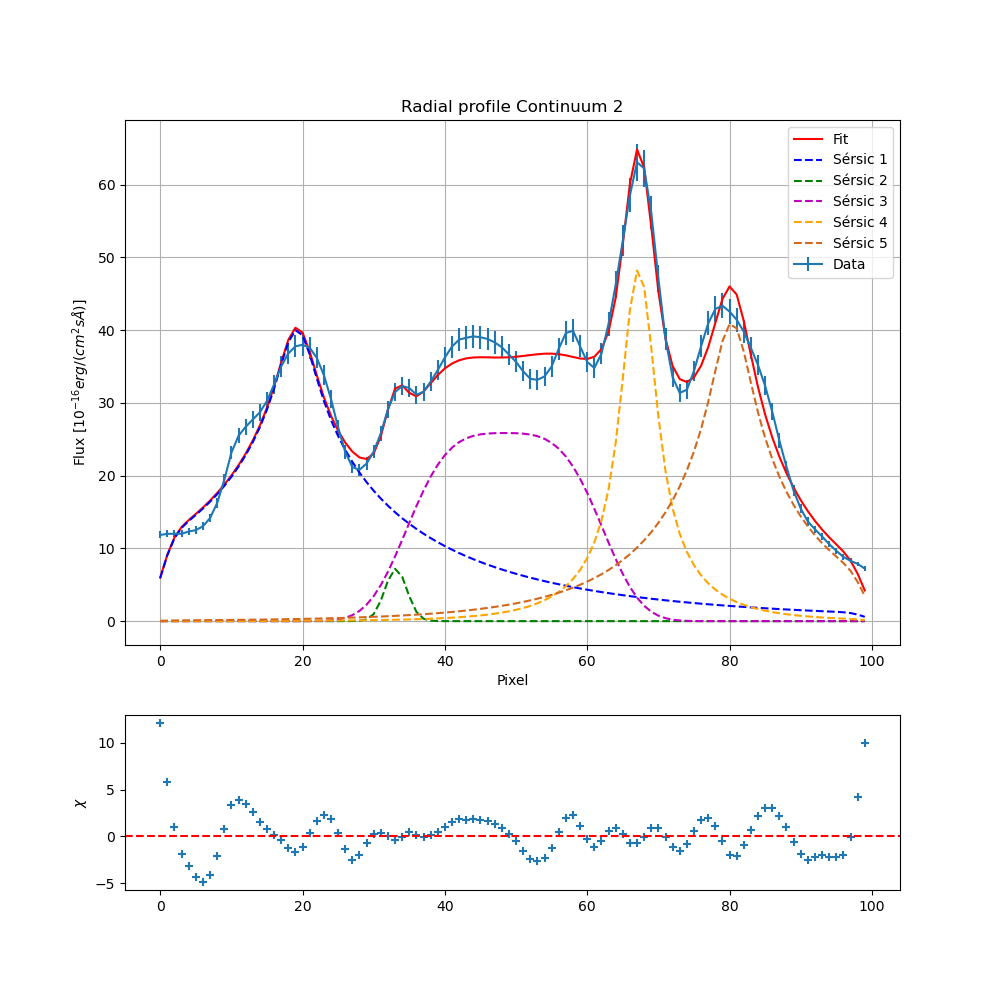

In [48]:
plot_curve(x_axes, params_curve_continuum_2, radial_profile_continuum_2, real_errors_c2, sigmas[-1], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_curve')

##  Continuum 3

Text(0.5, 1.0, 'Continuum 3')

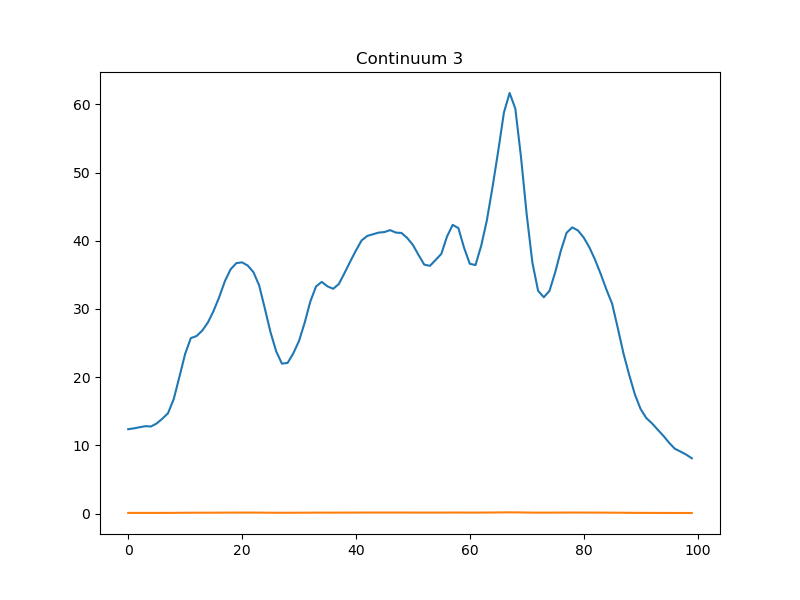

In [49]:
mask_continuum_3 = (wv > 6000)*(wv < 6500)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))
real_errors_c3 = np.sqrt(radial_profile_error_continuum_3**2+(sky_err[2])**2+(0.04*radial_profile_continuum_3)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

In [32]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_3, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 19217.88015964113
differential_evolution step 2: f(x)= 11250.546154127313
differential_evolution step 3: f(x)= 11250.546154127313
differential_evolution step 4: f(x)= 11250.546154127313
differential_evolution step 5: f(x)= 10972.090755133557
differential_evolution step 6: f(x)= 8484.391895900659
differential_evolution step 7: f(x)= 8484.391895900659
differential_evolution step 8: f(x)= 8484.391895900659
differential_evolution step 9: f(x)= 7003.747177191667
differential_evolution step 10: f(x)= 7003.747177191667
differential_evolution step 11: f(x)= 6527.5296723253905
differential_evolution step 12: f(x)= 5867.801107257813
differential_evolution step 13: f(x)= 4348.633114002975
differential_evolution step 14: f(x)= 3845.5086195646936
differential_evolution step 15: f(x)= 3845.5086195646936
differential_evolution step 16: f(x)= 3845.5086195646936
differential_evolution step 17: f(x)= 3845.5086195646936
differential_evolution step 18: f(x)= 3258.96906

Sérsic 1: I_e=3.8180, r_e=48.4380, n=1.3812, x_0=19.5000
Sérsic 2: I_e=0.0067, r_e=3.1696, n=7.1095, x_0=32.7029
Sérsic 3: I_e=20.0000, r_e=10.4687, n=0.2903, x_0=48.0831
Sérsic 4: I_e=2.0186, r_e=21.9623, n=2.1739, x_0=66.8835
Sérsic 5: I_e=6.1614, r_e=17.7517, n=1.1148, x_0=80.0225


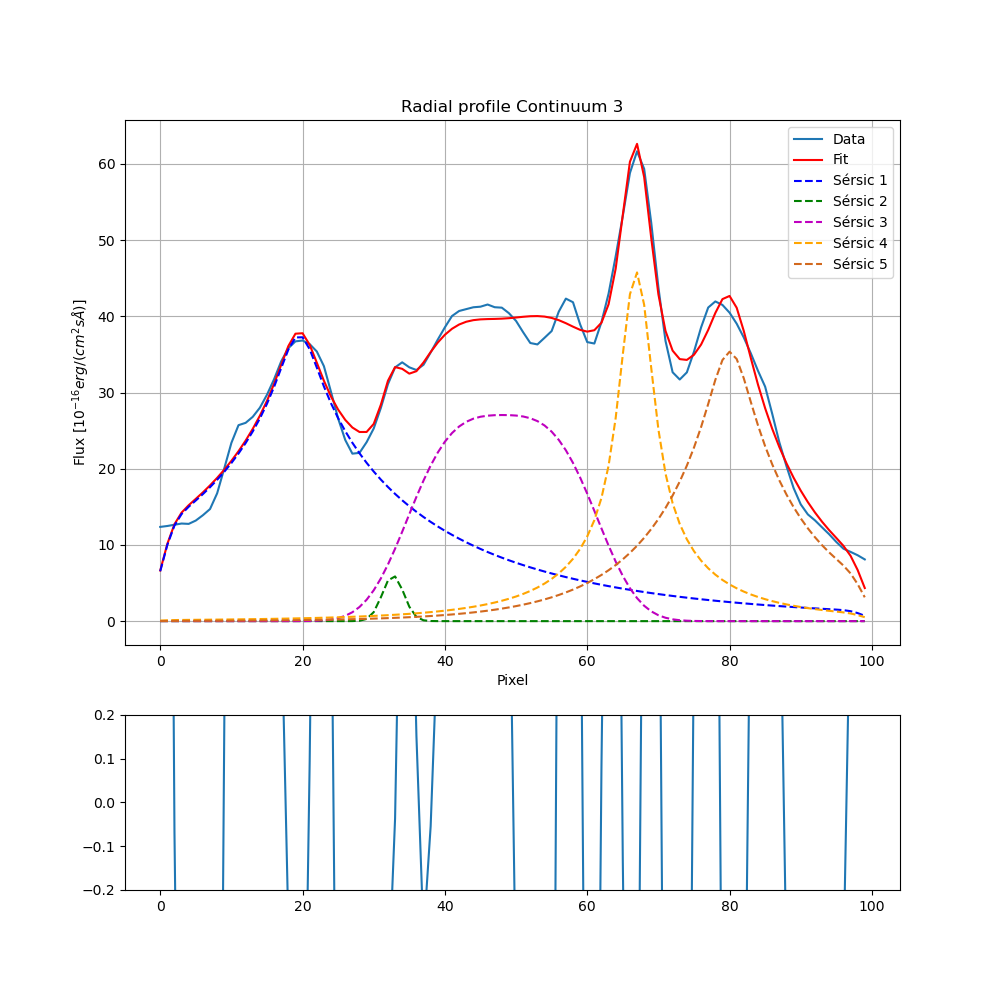

In [35]:
save_params_diff(best_params, radial_profile_continuum_3, real_errors_c3, sigmas[0],
    x_axes, n_component, line_name="Continuum_3", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_diff')

In [50]:
df = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC4904/FORS2.2022-02-07T08_36_57.209/Fit/Diff_params/Continuum_3_fit_diff.csv", index_col=0)
initial_guesses = np.concatenate([
    df['Component 1'].values,  # [I_e, r_e, n, x_0] per Component 1
    df['Component 2'].values,  # [I_e, r_e, n, x_0] per Component 2
    df['Component 3'].values,   # [I_e, r_e, n, x_0] per Component 3
    df['Component 4'].values,
    df['Component 5'].values
])
print(df)

     Component 1  Component 2  Component 3  Component 4  Component 5
I_e       3.8180       0.0067      20.0000       2.0186       6.1614
r_e      48.4380       3.1696      10.4687      21.9623      17.7517
n         1.3812       7.1095       0.2903       2.1739       1.1148
x_0      19.5000      32.7029      48.0831      66.8835      80.0225


In [51]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_3, covariance_continuum_3 = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes,
                                                             radial_profile_continuum_3, p0=result.x, sigma = real_errors_c3) #, bounds = bounds_list, maxfev = 10000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_3, dof_continuum_3, chi2_continuum_3 = save_params(params_curve_continuum_3, covariance_continuum_3, radial_profile_continuum_3,
                                                                          real_errors_c3, sigmas[0], x_axes, n_component, line_name="Continuum_3", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_10472\271829512.py:9: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_10472\271829512.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=1.0945, r_e=40.2911, n=1.9833, x_0=18.0406
Sérsic 2: I_e=0.3296, r_e=1.2780, n=4.9724, x_0=34.5868
Sérsic 3: I_e=3.4650, r_e=74.8133, n=1.3839, x_0=45.8399
Sérsic 4: I_e=0.8573, r_e=84.5748, n=2.5237, x_0=66.7923
Sérsic 5: I_e=13.0800, r_e=4.4414, n=0.3661, x_0=81.0188
[5.20288048e+00 2.72377551e+02 3.05276989e+00 4.50190630e-01
 1.78938802e+02 3.51837043e+02 7.54645814e+02 1.16465660e+00
 2.82772300e+00 2.34726988e+02 6.57575029e-01 1.04450258e+00
 7.38884206e+00 8.94029651e+02 5.49541256e+00 2.86966286e-01
 2.91346532e+00 7.02284182e-01 1.80300176e-01 5.05843503e-01]
7.667433936497337


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_10472\3127306944.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])


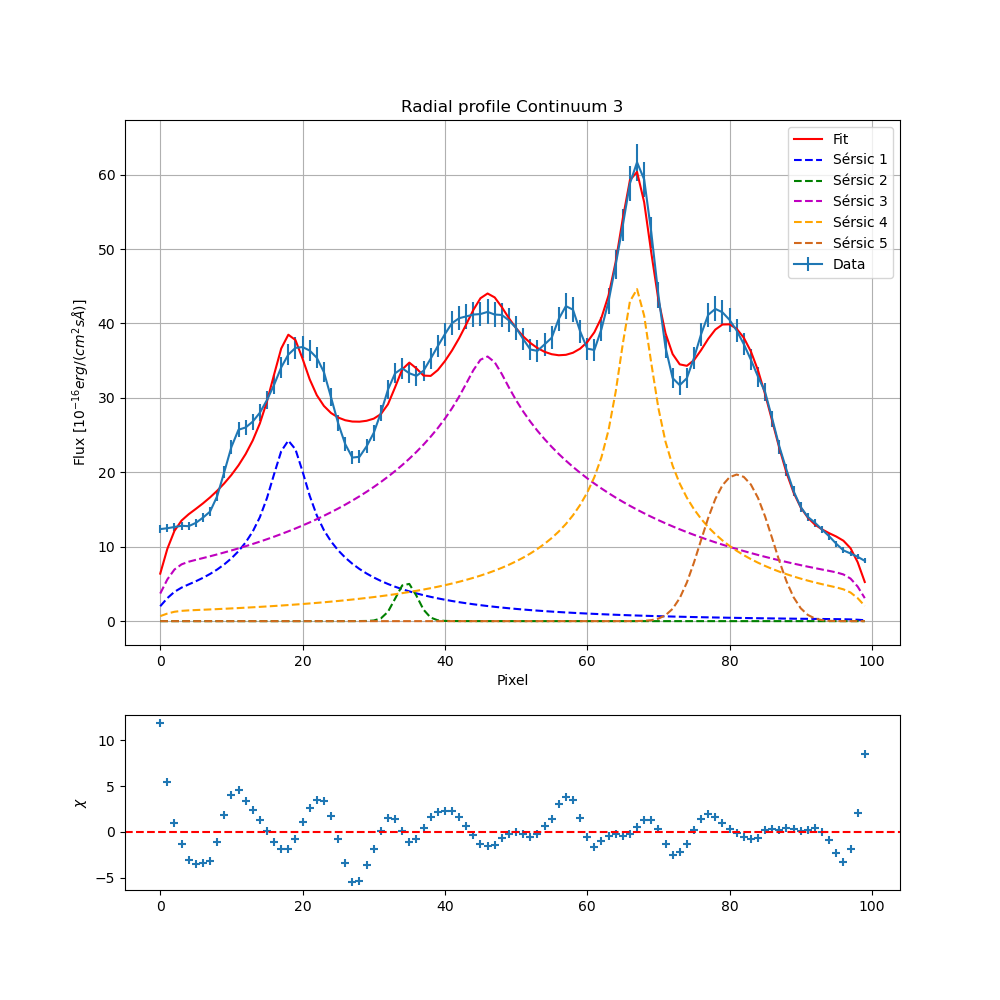

In [52]:
plot_curve(x_axes, params_curve_continuum_3, radial_profile_continuum_3, real_errors_c3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_curve')

## Chi squared save

In [53]:
chi_red = [chi2_reduced_continuum_1, chi2_reduced_continuum_2, chi2_reduced_continuum_3]
dof = [dof_continuum_1, dof_continuum_2, dof_continuum_3]
chi = [chi2_continuum_1, chi2_continuum_2, chi2_continuum_3]

d1 = {'Name': ['Continuum 1', 'Continuum 2', 'Continuum 3'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit_continuum.csv", index= False)